In [1]:
# Copyright 2022 The ML Notebooks Authors.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Linear Regression

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/mahalrs/ml-notebooks/blob/main/linear/linear_regression_scratch.ipynb"><img src="https://raw.githubusercontent.com/mahalrs/ml-notebooks/main/assets/icons/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/mahalrs/ml-notebooks/blob/main/linear/linear_regression_scratch.ipynb"><img src="https://raw.githubusercontent.com/mahalrs/ml-notebooks/main/assets/icons/github_mark_32px.png" />View source on GitHub</a>
  </td>
</table>

This notebook uses the classic Auto MPG dataset and demonstrates how to build a linear regression model to predict the fuel efficiency of the late-1970s and early 1980s automobiles.

## Setup

In [2]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

## Data Collection

### The Auto MPG dataset

The dataset is available from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).

### Get the data

Download and import the dataset using pandas.

In [3]:
path = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = [
    'MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration',
    'Model Year', 'Origin'
]

df = pd.read_csv(path,
                 names=column_names,
                 na_values='?',
                 comment='\t',
                 sep=' ',
                 skipinitialspace=True)
df.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


## Exploratory Data Analysis (EDA)

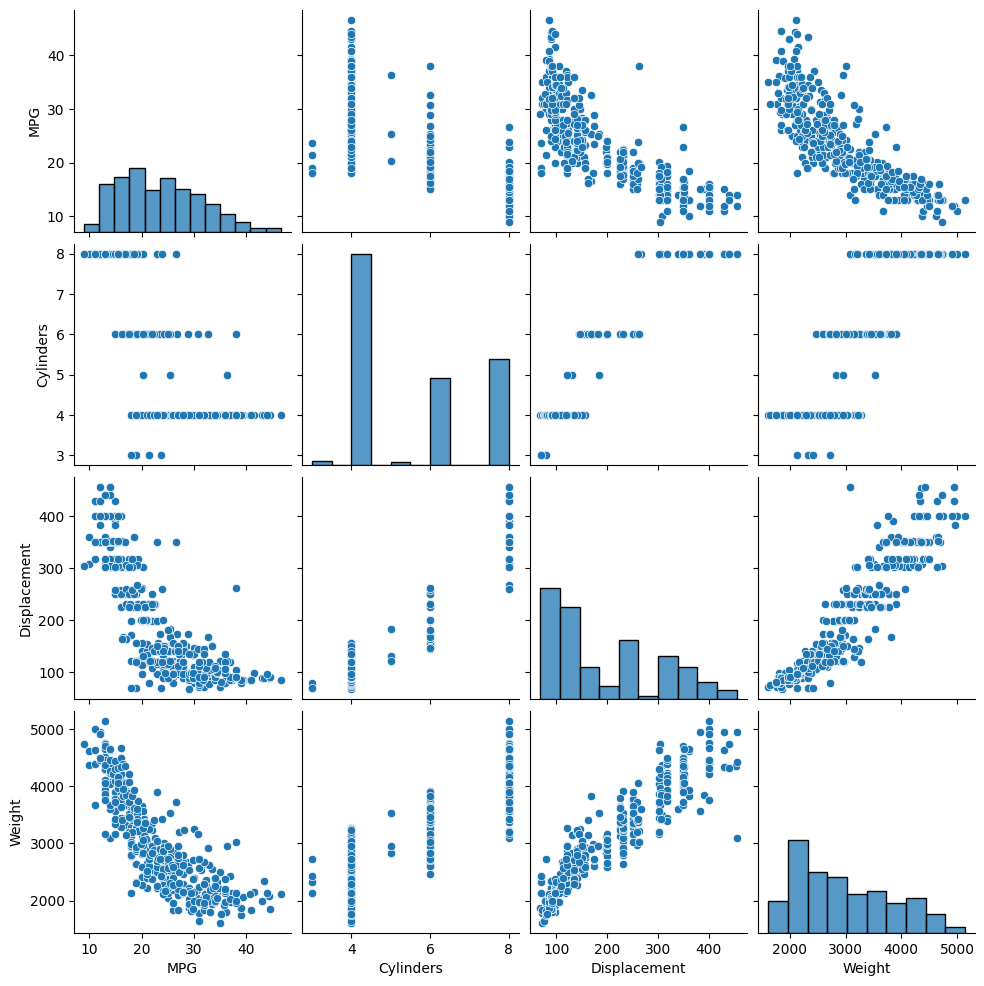

In [4]:
sns.pairplot(df[['MPG', 'Cylinders', 'Displacement', 'Weight']])

In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
Cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
Displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
Horsepower,392.0,104.469388,38.491160,46.0,75.000,93.5,126.000,230.0
Weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
Acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
Model Year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
Origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0


## Data Preparation

### Clean the data

Check data types.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


Check missing/unknown values.

In [7]:
df.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

Drop rows with unknown values.

In [8]:
df = df.dropna()

The `"Origin"` column is categorical, not numeric. So, the next step is to one-hot encode the values.

In [9]:
df = pd.get_dummies(df, prefix=['Origin'], columns=['Origin'], dummy_na=False)
df.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin_1,Origin_2,Origin_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,0,0
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,0,0
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,0,0
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,0,0
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,0,0


### Split features from labels

In [10]:
features = df.drop(columns=['MPG'])
labels = df['MPG']

### Split the data into development and test sets

Now split the dataset into a development set and a test set. You will use the test set in the final evaluation of your models.

In [11]:
dev_features, test_features, dev_labels, test_labels = train_test_split(
    features, labels, test_size=0.2, random_state=42)


### Normalize the data

In [12]:
scaler = StandardScaler()
dev_features = scaler.fit_transform(dev_features)
test_features = scaler.transform(test_features)

## Build a linear regression model

In [13]:
class LinearRegression():
    '''
    Linear regression implementation using the closed-form solution.
    '''

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        # Copy X and add a column of 1s
        X_ = X.copy()
        X_ = np.hstack([np.ones((X_.shape[0], 1)), X_])

        w = np.linalg.inv(X_.T @ X_) @ X_.T @ y

        self.intercept_ = w[0]
        self.coef_ = w[1:]

    def predict(self, X):
        return X.dot(self.coef_) + self.intercept_

    def score(self, X, y):
        predictions = X.dot(self.coef_) + self.intercept_
        return r2_score(y, predictions)

    def get_params(self, deep=True):
        return {}

    def set_params(self, **params):
        return self


model = LinearRegression()

## Train and evaluate your model

Evaluate model performance using cross-validation.

In [14]:
scores = cross_val_score(model,
                         dev_features,
                         dev_labels,
                         scoring='r2',
                         cv=5,
                         error_score='raise')

print('R^2 scores:\n', scores)
print('Mean R^2:\n', scores.mean())

R^2 scores:
 [0.81575617 0.81891121 0.77383085 0.76881803 0.8432326 ]
Mean R^2:
 0.8041097699184062


Fit a linear regression model on the development data.

In [15]:
model.fit(dev_features, dev_labels)

print('Coefficients:\n', model.coef_)
print('Intercept:\n', model.intercept_)

Coefficients:
 [-0.49306682  1.66783917 -0.73693562 -5.44734133  0.12559195  2.85140073
 -1.45971451 -0.03324789  0.02199842]
Intercept:
 23.599361022364228


Evaluate your model on the test data.

In [16]:
score = model.score(test_features, test_labels)
print('R^2:\n', score)

R^2:
 0.7834527163506237


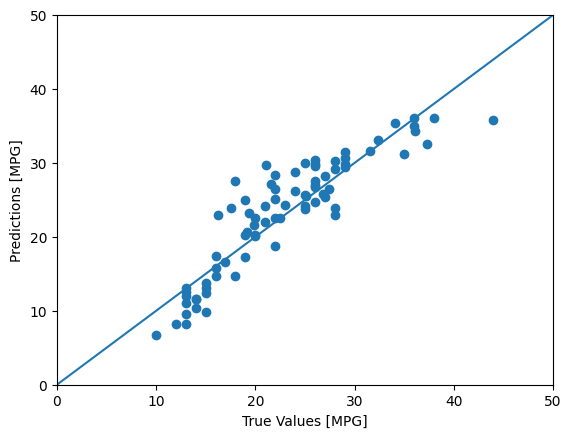

In [17]:
test_predictions = model.predict(test_features)

plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
lims = [0, 50]
plt.xlim(lims)
plt.ylim(lims)
plt.plot(lims, lims)

MSE:
 11.052699656472733


Text(0, 0.5, 'Count')

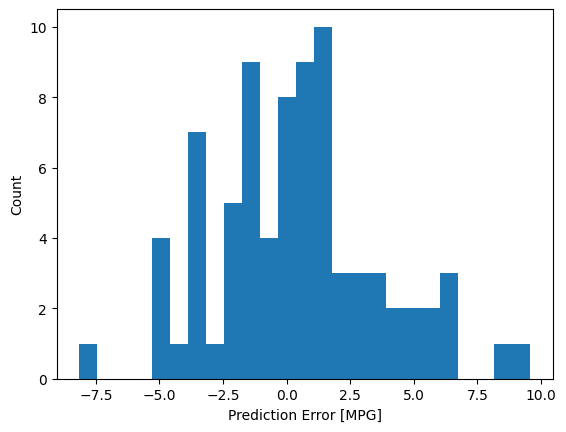

In [18]:
mse = mean_squared_error(test_labels, test_predictions)
print('MSE:\n', mse)

error = test_predictions - test_labels
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [MPG]')
plt.ylabel('Count')

Feature importance obtained from coefficients.

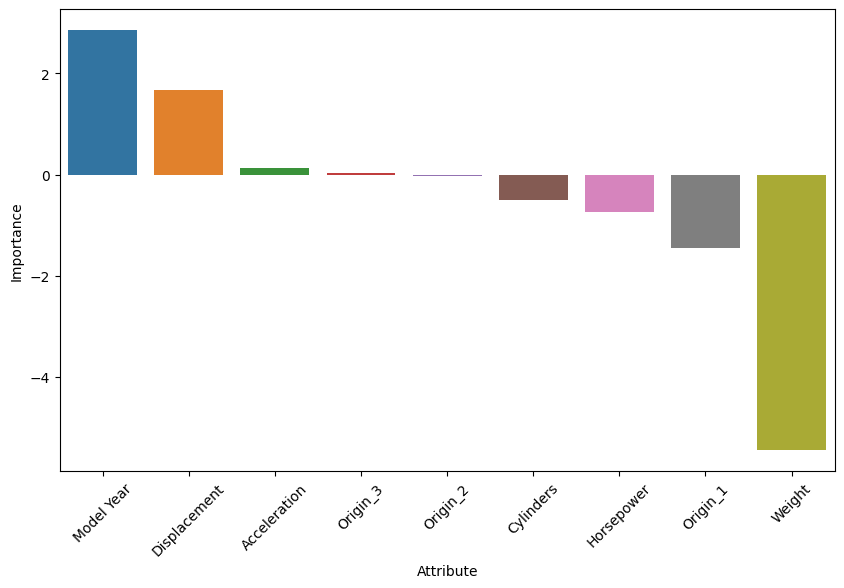

In [19]:
feature_importance_df = pd.DataFrame(data={
    'Attribute': features.columns,
    'Importance': model.coef_
})
feature_importance_df = feature_importance_df.sort_values(by='Importance',
                                                          ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(feature_importance_df, x='Attribute', y='Importance')
ax.tick_params(axis='x', rotation=45)

## Conclusion

You have trained a simple linear regression model.